##Business Context


##Data Context
(don't forget to add a picture)

In [54]:
#Importing neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing Data**

In [1]:
#loading dataset
df = pd.read_csv('/Users/siziphiwenogemani/AI & Application/Electronic_sales_Sep2023-Sep2024.csv')
df.head()

NameError: name 'pd' is not defined

In [ ]:
#Studying data type for each variable
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  str    
 3   Loyalty Member     20000 non-null  str    
 4   Product Type       20000 non-null  str    
 5   SKU                20000 non-null  str    
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  str    
 8   Payment Method     20000 non-null  str    
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  str    
 13  Shipping Type      20000 non-null  str    
 14  Add-ons Purchased  15132 non-null  str    
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4), str(9)
m

In [ ]:
# Checking missing values for each column
df.isnull().sum()

Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64

The dataset contains null values on the Gender and Add-ons Purchased. This is not a clean dataset and it requires cleaning before working on it.

In [ ]:
#Checking unique values, to see if there's no duplicate or spelling erros
categorial_columns = ['Gender','Loyalty Member', 'Product Type', 'SKU', 'Order Status', 'Purchase Date', 'Shipping Type','Add-ons Purchased']
for col in categorial_columns:
    print('column:', col)
    print('unique_values:', df[col].unique())
    print()

column: Gender
unique_values: <StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

column: Loyalty Member
unique_values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

column: Product Type
unique_values: <StringArray>
['Smartphone', 'Tablet', 'Laptop', 'Smartwatch', 'Headphones']
Length: 5, dtype: str

column: SKU
unique_values: <StringArray>
['SKU1004', 'SKU1002', 'SKU1005', 'SKU1001', 'SKU1003',  'LTP123',  'SMP234',
  'TBL345',  'HDP456',  'SWT567']
Length: 10, dtype: str

column: Order Status
unique_values: <StringArray>
['Cancelled', 'Completed']
Length: 2, dtype: str

column: Purchase Date
unique_values: <StringArray>
['2024-03-20', '2024-04-20', '2023-10-17', '2024-08-09', '2024-05-21',
 '2024-05-26', '2024-01-30', '2024-06-24', '2023-10-03', '2024-01-01',
 ...
 '2024-06-02', '2024-06-23', '2024-08-25', '2024-02-16', '2023-12-28',
 '2024-07-14', '2024-09-06', '2024-07-28', '2023-11-23', '2023-11-25']
Length: 366, dtype: str

column: Shipping Type
unique_values: <Stri

In [ ]:
#Add-ons Purchased column needed more studying for cleaning and preprocessing purposes
df['Add-ons Purchased'].unique()

<StringArray>
[                          'Accessory,Accessory,Accessory',
                                            'Impulse Item',
                                                       nan,
                               'Impulse Item,Impulse Item',
                                               'Accessory',
                                  'Impulse Item,Accessory',
                     'Extended Warranty,Extended Warranty',
                     'Impulse Item,Accessory,Impulse Item',
                             'Accessory,Extended Warranty',
        'Extended Warranty,Impulse Item,Extended Warranty',
                        'Accessory,Impulse Item,Accessory',
                          'Impulse Item,Extended Warranty',
                'Impulse Item,Accessory,Extended Warranty',
                          'Extended Warranty,Impulse Item',
                                     'Accessory,Accessory',
                                       'Extended Warranty',
                          

**Data Cleaning & Prepocessing**

In [3]:
#Removing repeated categories for each row
#Ref[1]

df['Add-ons Purchased'] = df['Add-ons Purchased'].apply(
    lambda x: ','.join(sorted(set([i.strip() for i in str(x).split(',')]))))

NameError: name 'df' is not defined

In [ ]:
df.tail()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,nan,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,nan,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Accessory, Extended Warranty, Impulse Item",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Accessory, Extended Warranty",101.34
19999,19998,27,NaN,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,2024-01-29,Expedited,nan,0.00


The Add-ons Purchased column contained repeated categories for each transcation. For the purpose of this study, these repetations were consolidated so that each add on category could appear once per transcation.  

In [ ]:
df[df['Gender'].isnull()]

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
19999,19998,27,NaN,Yes,Laptop,LTP123,4,Completed,Bank Transfer,674.32,674.32,1,2024-01-29,Expedited,nan,0.0


In [ ]:
df['Gender'] = df['Gender'].fillna('Unknown')

I did not want to assume Gender, as it is also against society standard to assume gender.

In [ ]:
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

In [ ]:
df[['Gender','Add-ons Purchased']].isnull().sum()

Gender               0
Add-ons Purchased    0
dtype: int64

In [ ]:
# Converting Purchase Date from string to object, as it is currently reading as a text. 
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [ ]:
df['year'] = df['Purchase Date'].dt.year
df['month'] = df['Purchase Date'].dt.month
df['day'] = df['Purchase Date'].dt.day

##Exploratory Data Analysis

**Which product generate highest sales?**
- This help management make informed decisions regarding product focus and resource allocation for instance inventory allocation, makerting focus, and supplier partnerships. 


In [ ]:
df.groupby('Product Type')['Total Price'].sum().sort_values(ascending=False)

Product Type
Smartphone    21516754.69
Smartwatch    14036273.06
Laptop        12296239.97
Tablet        11712000.41
Headphones     4041400.24
Name: Total Price, dtype: float64

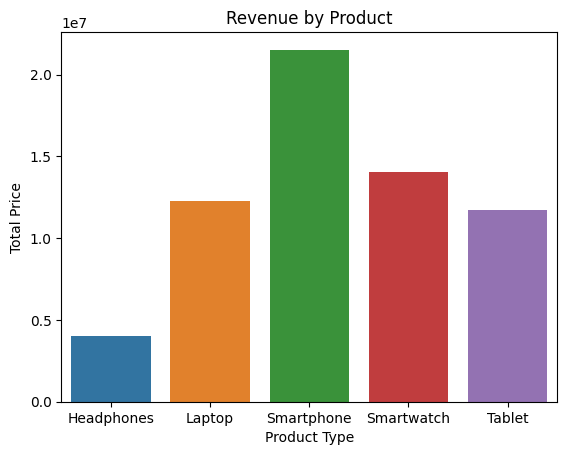

In [ ]:
revenue_product = df.groupby('Product Type')['Total Price'].sum().reset_index()
sns.barplot(x='Product Type', y='Total Price', hue='Product Type', data=revenue_product)
plt.title ('Revenue by Product')
plt.xlabel('Product Type')
plt.ylabel('Total Price')
plt.show()

In [ ]:
# checking if revenue could be influenced by product pricing
price_range_per_product = df.groupby('Product Type')['Unit Price'].agg(['min', 'max']).reset_index()
print(price_range_per_product)

  Product Type     min      max
0   Headphones  361.18   826.04
1       Laptop  463.96   932.03
2   Smartphone   20.75  1139.68
3   Smartwatch  459.50   844.83
4       Tablet  247.03   786.41


- As shown by analysis above Smartphone generate highest revenue as compared to other electronic products. This could be influenced by strong customer demand. These results indicate that management need to consider prioritising inventory availability, advertisement, and supplier relationship for highest revenue generating products.

**Do loyalty members contribute much to the highest revenue than non members?**

<function matplotlib.pyplot.show(close=None, block=None)>

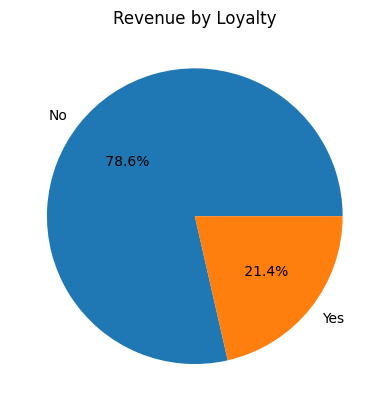

In [ ]:
#loyalty = df[df['Loyalty Member'] == 'Yes']
revenue_by_loyalty = df.groupby ('Loyalty Member')['Total Price'].sum()
revenue_by_loyalty.plot.pie(title = 'Revenue by Loyalty', autopct=' %1.1f%%')
plt.ylabel(None)
plt.show


**What drives cancellation of loyalty membership**
- To understand when customers cancel loyalty membership and identify potential potention retention problems.

In [ ]:
df['Loyalty Member'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

**Are loyalty member likely to purchase add-on**

In [ ]:
#total_loyalty = df[df['Loyalty Member'] == 'Yes'].shape[]
Add_ons_loyalty = df[(df['Loyalty Member'] == 'Yes')(df['Add-ons Purchased'] != 'None')].shape[0]

TypeError: 'Series' object is not callable

In [ ]:

loyalty = df[df['Loyalty Member'] == 'Yes']
#Add_ons_loyalty = loyalty[loyalty['Add-ons Purchased'] != 'None']
revenue_by_loyalty = df.groupby ('loyalty')['Add-ons Purchased'].sum()
revenue_by_loyalty.plot.pie(title = 'Revenue by Loyalty', autopct=' %1.1f%%')
plt.ylabel(None)
plt.show


KeyError: 'loyalty'

**Which products are likely to be purchased with add-on**

In [ ]:
df['Add-ons Purchased'].unique()

<StringArray>
[                                 'Accessory',
                               'Impulse Item',
                                        'nan',
                    'Accessory, Impulse Item',
                          'Extended Warranty',
               'Accessory, Extended Warranty',
            'Extended Warranty, Impulse Item',
 'Accessory, Extended Warranty, Impulse Item']
Length: 8, dtype: str

In [ ]:
add_on_products = df.groupby(['Product Type', 'Add-ons Purchased']).size().reset_index(name='count')
print(add_on_products)

   Product Type                           Add-ons Purchased  count
0    Headphones                                   Accessory    244
1    Headphones                Accessory, Extended Warranty    218
2    Headphones  Accessory, Extended Warranty, Impulse Item    119
3    Headphones                     Accessory, Impulse Item    222
4    Headphones                           Extended Warranty    223
5    Headphones             Extended Warranty, Impulse Item    243
6    Headphones                                Impulse Item    259
7    Headphones                                         nan    483
8        Laptop                                   Accessory    453
9        Laptop                Accessory, Extended Warranty    407
10       Laptop  Accessory, Extended Warranty, Impulse Item    213
11       Laptop                     Accessory, Impulse Item    486
12       Laptop                           Extended Warranty    500
13       Laptop             Extended Warranty, Impulse Item   

In [ ]:
none_addon_stats = df.groupby('Product Type')['Add-ons Purchased'].apply(lambda x:(x == 'nan').sum()).sort_values(ascending=False)
print(none_addon_stats)

Product Type
Smartphone    1486
Tablet         987
Laptop         970
Smartwatch     942
Headphones     483
Name: Add-ons Purchased, dtype: int64


Since Smartphone are the most sold as seen on the analysis above, the management can take advantage 

In [ ]:
df['add_on_products'] = df['Add-ons Purchased'].apply(lambda x:0 if x=='nan' else 1)

In [ ]:
add_on_activity = df.groupby('Product Type').agg(
    total_ordes = ('Customer ID', 'count'),
    add_on_orders = ('add_on_products', 'sum'))

add_on_activity ['add_on_rate'] = add_on_activity['add_on_orders'] / add_on_activity['total_ordes']
print(add_on_activity)


              total_ordes  add_on_orders  add_on_rate
Product Type                                         
Headphones           2011           1528     0.759821
Laptop               3973           3003     0.755852
Smartphone           5978           4492     0.751422
Smartwatch           3934           2992     0.760549
Tablet               4104           3117     0.759503


**Is there any relationship between rating and quanting sold**

In [ ]:
df.groupby('Product Type')['Rating'].mean().sort_values(ascending=False)

Product Type
Smartphone    3.319003
Tablet        3.016326
Smartwatch    2.994408
Headphones    2.993536
Laptop        2.984898
Name: Rating, dtype: float64

In [ ]:
df['Rating'].corr(df['Quantity'])

np.float64(-0.008587191195919016)

In [ ]:
#selfnote - make a bar graph
df.groupby('Product Type')['Quantity'].sum().sort_values(ascending=False)

Product Type
Smartphone    32660
Tablet        22653
Smartwatch    21631
Laptop        21584
Headphones    11183
Name: Quantity, dtype: int64

**Which period shows the highest purchased acttivity and which product was purchased?**
- line graph


In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Loyalty Member', 'Product Type', 'SKU',
       'Rating', 'Order Status', 'Payment Method', 'Total Price', 'Unit Price',
       'Quantity', 'Purchase Date', 'Shipping Type', 'Add-ons Purchased',
       'Add-on Total', 'year', 'month', 'day'],
      dtype='str')

In [ ]:
#df['month'] = df['Purchase Date'].dt.month
#df.groupby('month')['Quantity'].sum()
df['YearMonth'] = df['Purchase Date'].dt.to_period('M')

In [ ]:
monthly_activity = df.groupby('YearMonth')['Quantity'].sum()
print(monthly_activity)

YearMonth
2023-09     1023
2023-10     5027
2023-11     4310
2023-12     4352
2024-01    11185
2024-02     9882
2024-03    10697
2024-04    10748
2024-05    11230
2024-06    10903
2024-07    10948
2024-08    11102
2024-09     8304
Freq: M, Name: Quantity, dtype: int64


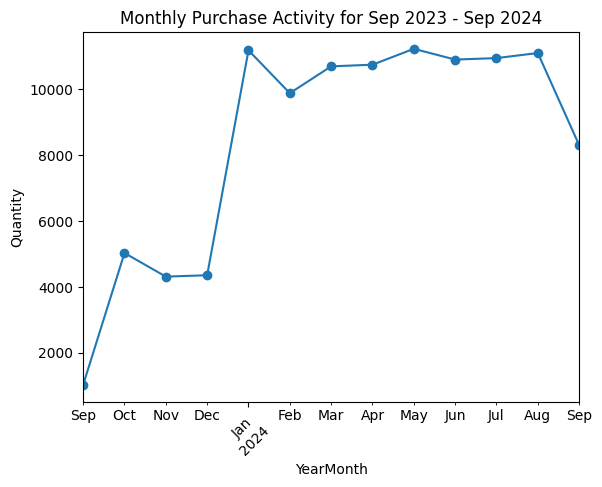

In [ ]:
monthly_activity.plot(kind='line', marker='o')
plt.title('Monthly Purchase Activity for Sep 2023 - Sep 2024')
plt.xlabel('YearMonth')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#monthly_product_activity = df.groupby(['YearMonth', 'Product Type'])['Quantity'].sum().reset_index()
#print(monthly_product_activity)

   YearMonth Product Type  Quantity
0    2023-09       Laptop       186
1    2023-09   Smartphone       342
2    2023-09   Smartwatch       198
3    2023-09       Tablet       297
4    2023-10       Laptop       918
..       ...          ...       ...
56   2024-09   Headphones       911
57   2024-09       Laptop      1488
58   2024-09   Smartphone      2560
59   2024-09   Smartwatch      1609
60   2024-09       Tablet      1736

[61 rows x 3 columns]


In [ ]:
monthly_product_activity = df.groupby(['YearMonth', 'Product Type'])['Quantity'].sum().reset_index()
top_products_monthly = monthly_product_activity.loc[monthly_product_activity.groupby('YearMonth')['Quantity'].idxmax()]
print(top_products_monthly)

   YearMonth Product Type  Quantity
1    2023-09   Smartphone       342
5    2023-10   Smartphone      2047
9    2023-11   Smartphone      1821
13   2023-12   Smartphone      1717
18   2024-01   Smartphone      3228
23   2024-02   Smartphone      2518
28   2024-03   Smartphone      3117
33   2024-04   Smartphone      2976
38   2024-05   Smartphone      3065
43   2024-06   Smartphone      3116
48   2024-07   Smartphone      2928
53   2024-08   Smartphone      3225
58   2024-09   Smartphone      2560


**What is the average spending per customer**